[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DavidNaranjo1237/NATICUSdroid/blob/main/notebooks/05_SVM.ipynb)


03. SVM NATICUSdroid

In [1]:
from pathlib import Path
import os
import subprocess
import sys

REPO_URL = 'https://github.com/DavidNaranjo1237/NATICUSdroid.git'
REPO_DIR = Path('/content/NATICUSdroid')

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score  # noqa: F401
from sklearn.model_selection import GridSearchCV, StratifiedKFold

_bootstrap_dependencies = (
    np,
    pd,
    RandomForestClassifier,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    GridSearchCV,
    StratifiedKFold,
)
print(f'Bootstrap imports loaded: {len(_bootstrap_dependencies)}')

def is_colab() -> bool:
    return 'COLAB_RELEASE_TAG' in os.environ or 'google.colab' in sys.modules

def find_repo_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'src' / 'prepare_data.py').exists():
            return candidate
    return REPO_DIR if is_colab() else Path.cwd()

repo_root = find_repo_root()
if is_colab() and not (repo_root / 'src' / 'prepare_data.py').exists():
    if not repo_root.exists():
        subprocess.run(['git', 'clone', REPO_URL, str(repo_root)], check=True)
    else:
        print(f'Repository directory already exists at {repo_root}.')

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print(f'Repository root: {repo_root}')
print('Imports listos para el entrenamiento del SVM.')

Bootstrap imports loaded: 12
Repository root: c:\Users\EXITOPC\Desktop\Certificados\NATICUSdroid
Imports listos para el entrenamiento del SVM.


Preprocesado

In [2]:
from src.prepare_data import prepare_dataset

results = prepare_dataset()
summary = results['summary']
artifacts = results['artifacts']
X_train = results['X_train']
X_test = results['X_test']
y_train = results['y_train']
y_test = results['y_test']

print('Resumen del dataset')
print(summary)
print('')
print('Artefactos generados')
for name, value in artifacts.items():
    print(f'{name}: {value}')

print('')
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

Resumen del dataset
{'rows': 29332, 'columns': 87, 'feature_columns': 86, 'missing_values': 0, 'class_distribution': {'0': 14632, '1': 14700}, 'class_distribution_percent': {'0': 49.8841, '1': 50.1159}}

Artefactos generados
train_features: C:\Users\EXITOPC\Desktop\Certificados\NATICUSdroid\data\processed\X_train.csv
test_features: C:\Users\EXITOPC\Desktop\Certificados\NATICUSdroid\data\processed\X_test.csv
train_target: C:\Users\EXITOPC\Desktop\Certificados\NATICUSdroid\data\processed\y_train.csv
test_target: C:\Users\EXITOPC\Desktop\Certificados\NATICUSdroid\data\processed\y_test.csv
train_full: C:\Users\EXITOPC\Desktop\Certificados\NATICUSdroid\data\processed\train.csv
test_full: C:\Users\EXITOPC\Desktop\Certificados\NATICUSdroid\data\processed\test.csv
metadata: C:\Users\EXITOPC\Desktop\Certificados\NATICUSdroid\data\processed\split_metadata.json

X_train shape: (20532, 86)
X_test shape: (8800, 86)
y_train shape: (20532,)
y_test shape: (8800,)


In [3]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)

# Configuración estética de los gráficos
sns.set_theme(style="whitegrid", palette="deep")
SEED = 42
np.random.seed(SEED)

# 1. FUNCIÓN PARA INTERVALOS DE CONFIANZA (BOOTSTRAP)
def calcular_intervalo_confianza(y_real, y_pred, metrica_fn, iteraciones=1000, alfa=0.05):
    """Calcula el IC del 95% usando remuestreo Bootstrap."""
    rng = np.random.default_rng(SEED)
    n = len(y_real)
    estadisticos = np.empty(iteraciones)

    for i in range(iteraciones):
        indices = rng.integers(0, n, n)
        estadisticos[i] = metrica_fn(y_real[indices], y_pred[indices])

    limite_inf = np.percentile(estadisticos, 100 * (alfa / 2))
    limite_sup = np.percentile(estadisticos, 100 * (1 - alfa / 2))
    return limite_inf, limite_sup

In [4]:
# 2. ASEGURAR FORMATO NUMPY PARA EVITAR ERRORES DE ÍNDICES
X_tr = np.asarray(X_train)
y_tr = np.asarray(y_train)
X_te = np.asarray(X_test)
y_te = np.asarray(y_test)

In [5]:
# 3. VALIDACIÓN CRUZADA - BÚSQUEDA DE HIPERPARÁMETROS
valores_C = [0.01, 0.1, 1, 10, 100]
validador_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
resultados_cv = []

print("Iniciando Validación Cruzada para LinearSVC...\n")
tiempo_inicio = time.time()

for c in valores_C:
    metricas_fold = {'acc': [], 'f1': [], 'auc': [], 'vectores_soporte': []}

    for train_idx, val_idx in validador_kfold.split(X_tr, y_tr):
        # Separación por pliegues
        X_kf_train, X_kf_val = X_tr[train_idx], X_tr[val_idx]
        y_kf_train, y_kf_val = y_tr[train_idx], y_tr[val_idx]

        # Escalado de datos independiente por pliegue (Evita Data Leakage)
        escalador = StandardScaler()
        X_kf_train_s = escalador.fit_transform(X_kf_train)
        X_kf_val_s = escalador.transform(X_kf_val)

        # Entrenamiento
        modelo_svm = LinearSVC(C=c, loss='squared_hinge', max_iter=4000,
                               random_state=SEED, dual="auto")
        modelo_svm.fit(X_kf_train_s, y_kf_train)

        # Predicciones
        preds_val = modelo_svm.predict(X_kf_val_s)
        decision_val = modelo_svm.decision_function(X_kf_val_s)

        # Registro de métricas
        metricas_fold['acc'].append(accuracy_score(y_kf_val, preds_val))
        metricas_fold['f1'].append(f1_score(y_kf_val, preds_val, zero_division=0))
        metricas_fold['auc'].append(roc_auc_score(y_kf_val, decision_val))

        # Aproximación de Vectores de Soporte (Muestras dentro del margen)
        decision_train = modelo_svm.decision_function(X_kf_train_s)
        margen = y_kf_train * decision_train
        pct_sv = np.mean(margen <= 1.00000001) * 100
        metricas_fold['vectores_soporte'].append(pct_sv)

    # Promediar los pliegues para el parámetro C actual
    resultados_cv.append({
        "C": c,
        "F1_Promedio": np.mean(metricas_fold['f1']),
        "F1_Std": np.std(metricas_fold['f1']),
        "Acc_Promedio": np.mean(metricas_fold['acc']),
        "AUC_Promedio": np.mean(metricas_fold['auc']),
        "Pct_SV_Aprox": np.mean(metricas_fold['vectores_soporte'])
    })

print(f"Búsqueda finalizada en {time.time() - tiempo_inicio:.2f} segundos.\n")
df_resultados = pd.DataFrame(resultados_cv)
display(df_resultados)

Iniciando Validación Cruzada para LinearSVC...

Búsqueda finalizada en 8.02 segundos.



,C,F1_Promedio,F1_Std,Acc_Promedio,AUC_Promedio,Pct_SV_Aprox
0,0.01,0.960670,0.002245,0.960354,0.988719,65.386963
1,0.10,0.960520,0.002220,0.960208,0.988675,64.699008
2,1.00,0.960614,0.002305,0.960306,0.988663,64.606470
3,10.00,0.960567,0.002286,0.960257,0.988659,64.606470
4,100.00,0.960567,0.002286,0.960257,0.988662,64.607688


In [6]:
# 4. SELECCIÓN Y ENTRENAMIENTO DEL MODELO FINAL
# Encontrar el mejor C basado en el F1-Score más alto
mejor_c = df_resultados.loc[df_resultados["F1_Promedio"].idxmax(), "C"]
print(f"\nEntrenando modelo final con la mejor regularización: C = {mejor_c}")

# Escalar el conjunto de entrenamiento completo
escalador_final = StandardScaler()
X_tr_final = escalador_final.fit_transform(X_tr)
X_te_final = escalador_final.transform(X_te)

# Entrenar el modelo definitivo
svm_definitivo = LinearSVC(C=mejor_c, loss='squared_hinge', max_iter=5000,
                           random_state=SEED, dual="auto")
svm_definitivo.fit(X_tr_final, y_tr)

# Predicciones finales en el conjunto de PRUEBA (Test)
preds_test = svm_definitivo.predict(X_te_final)
decisiones_test = svm_definitivo.decision_function(X_te_final)

# Calcular IC95% para test
ic_acc = calcular_intervalo_confianza(y_te, preds_test, accuracy_score)
ic_f1 = calcular_intervalo_confianza(y_te, preds_test, lambda a, b: f1_score(a, b, zero_division=0))

print("\n" + "="*35)
print(" RESULTADOS EN CONJUNTO DE PRUEBA")
print("="*35)
print(f"Exactitud (Accuracy) : {accuracy_score(y_te, preds_test):.4f}  | IC 95%: [{ic_acc[0]:.4f}, {ic_acc[1]:.4f}]")
print(f"Precisión (Precision): {precision_score(y_te, preds_test, zero_division=0):.4f}")
print(f"Sensibilidad (Recall): {recall_score(y_te, preds_test, zero_division=0):.4f}")
print(f"F1-Score             : {f1_score(y_te, preds_test, zero_division=0):.4f}  | IC 95%: [{ic_f1[0]:.4f}, {ic_f1[1]:.4f}]")
print(f"Área ROC (AUC)       : {roc_auc_score(y_te, decisiones_test):.4f}")
print("="*35)


Entrenando modelo final con la mejor regularización: C = 0.01

 RESULTADOS EN CONJUNTO DE PRUEBA
Exactitud (Accuracy) : 0.9591  | IC 95%: [0.9549, 0.9631]
Precisión (Precision): 0.9540
Sensibilidad (Recall): 0.9649
F1-Score             : 0.9594  | IC 95%: [0.9551, 0.9636]
Área ROC (AUC)       : 0.9885


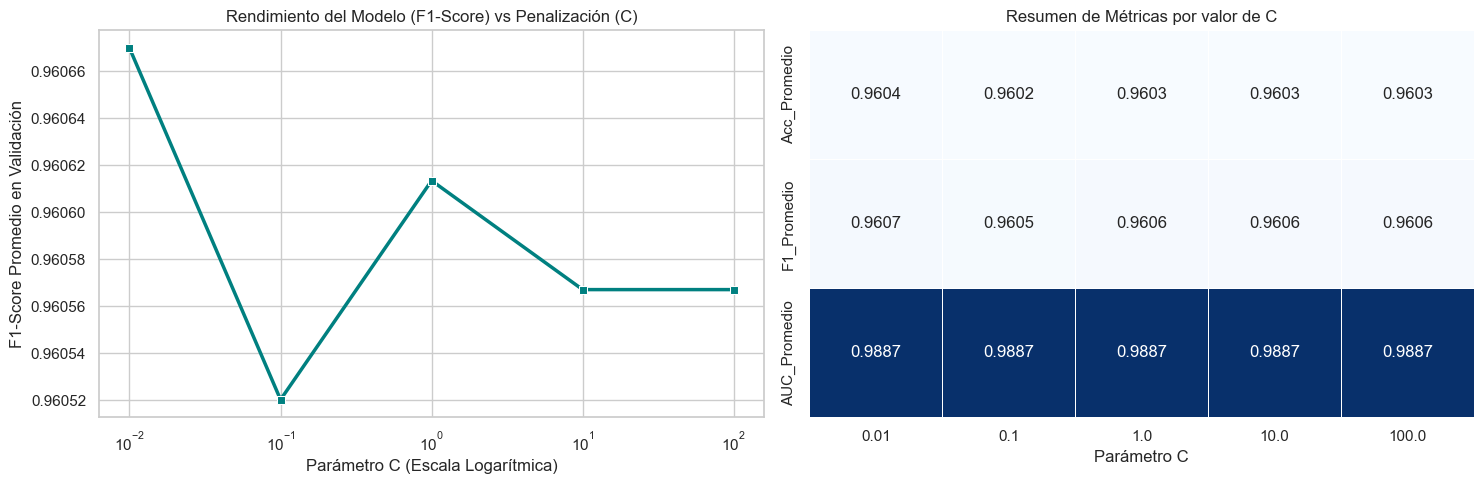

In [7]:
# 5. VISUALIZACIÓN MULTIPANEL DE LOS RESULTADOS
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico de líneas para F1 vs C
sns.lineplot(data=df_resultados, x="C", y="F1_Promedio", marker='s', ax=ax1, color='teal', linewidth=2.5)
ax1.set_xscale('log')
ax1.set_title('Rendimiento del Modelo (F1-Score) vs Penalización (C)')
ax1.set_xlabel('Parámetro C (Escala Logarítmica)')
ax1.set_ylabel('F1-Score Promedio en Validación')

# Mapa de calor de las métricas principales
mapa_datos = df_resultados.set_index("C")[["Acc_Promedio", "F1_Promedio", "AUC_Promedio"]].T
sns.heatmap(mapa_datos, annot=True, cmap='Blues', fmt=".4f", cbar=False, ax=ax2, linewidths=.5)
ax2.set_title('Resumen de Métricas por valor de C')
ax2.set_xlabel('Parámetro C')

plt.tight_layout()
plt.show()

## 8. Sección de gráficas y métricas para el informe

En esta sección se generan las métricas comparativas y las figuras finales del modelo para incorporarlas al informe.


c:\Users\EXITOPC\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
c:\Users\EXITOPC\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


    Modelo Split  Accuracy  Precision   Recall  F1-score  Especificidad  ROC-AUC    IC95 Accuracy          IC95 F1
SVM lineal Train  0.961183   0.956087 0.966958  0.961492       0.955380 0.989258 [0.9586, 0.9638] [0.9588, 0.9640]
SVM lineal  Test  0.959091   0.954036 0.964853  0.959414       0.953303 0.988458 [0.9549, 0.9631] [0.9551, 0.9636]


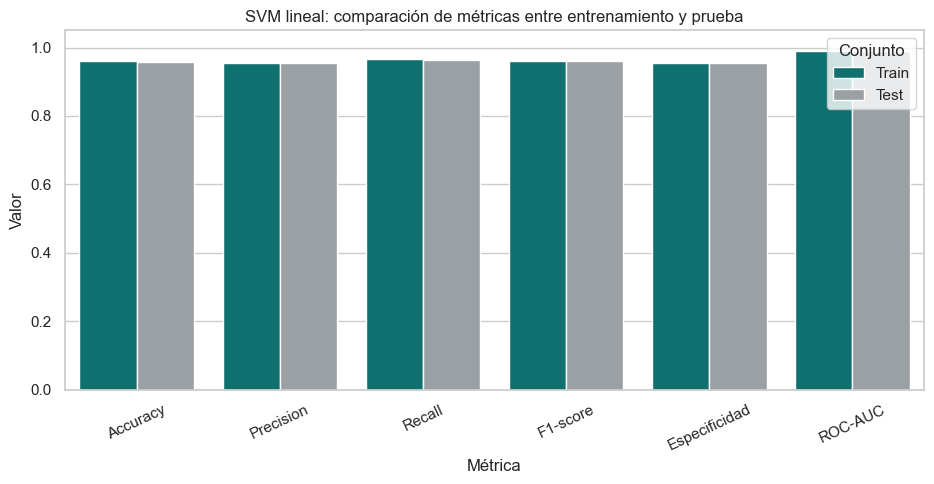

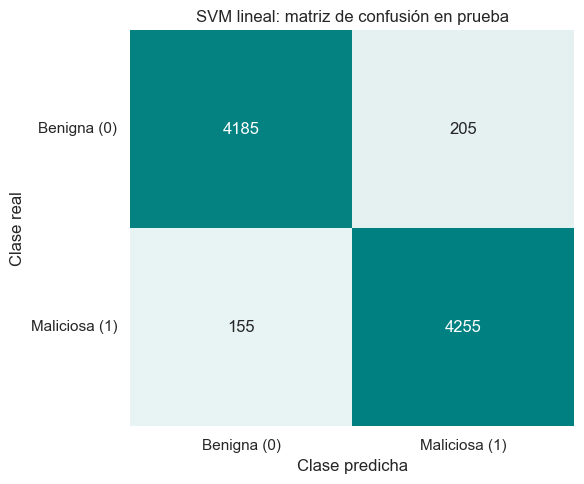

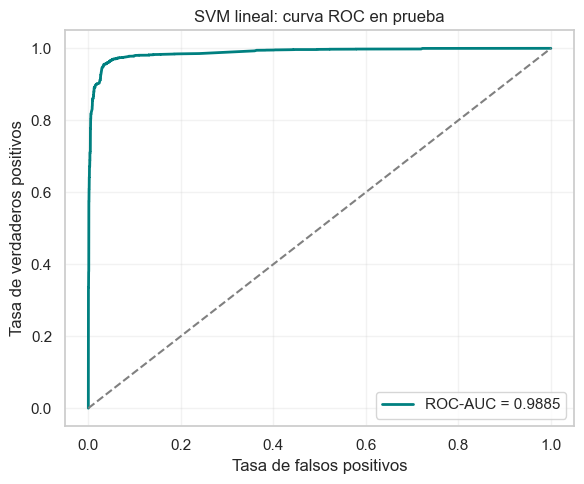

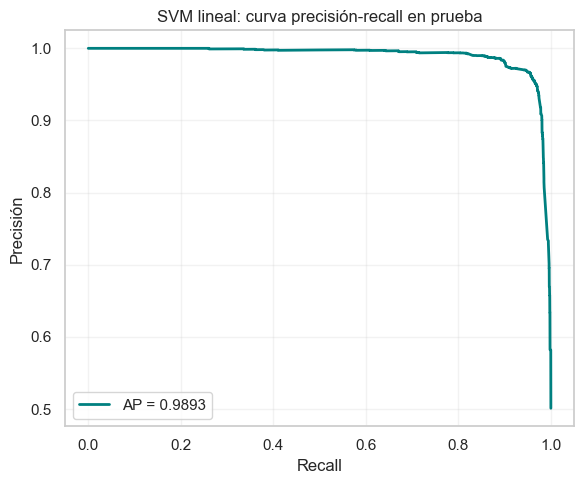

Figuras guardadas en: C:\Users\EXITOPC\Desktop\Certificados\NATICUSdroid\notebooks\Informe_latex\figuras


In [8]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import subprocess

try:
    import seaborn as sns
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn"])
    import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)
from src.prepare_data import prepare_dataset


def buscar_raiz_repo(inicio=Path.cwd().resolve()):
    for ruta in [inicio, *inicio.parents]:
        if (ruta / "Informe_latex").exists() and (ruta / "data").exists():
            return ruta
    return inicio


def bootstrap_ci(y_real, y_pred, metric_fn, n_iter=1000, seed=42):
    rng = np.random.default_rng(seed)
    y_real = np.asarray(y_real)
    y_pred = np.asarray(y_pred)
    n = len(y_real)
    valores = []
    for _ in range(n_iter):
        idx = rng.integers(0, n, n)
        valores.append(metric_fn(y_real[idx], y_pred[idx]))
    return np.percentile(valores, [2.5, 97.5])


def calcular_metricas(y_real, y_pred, y_score, nombre_modelo, split):
    cm = confusion_matrix(y_real, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    acc_ci = bootstrap_ci(y_real, y_pred, accuracy_score)
    f1_ci = bootstrap_ci(y_real, y_pred, f1_score)
    return {
        "Modelo": nombre_modelo,
        "Split": split,
        "Accuracy": accuracy_score(y_real, y_pred),
        "Precision": precision_score(y_real, y_pred, zero_division=0),
        "Recall": recall_score(y_real, y_pred, zero_division=0),
        "F1-score": f1_score(y_real, y_pred, zero_division=0),
        "Especificidad": specificity,
        "ROC-AUC": roc_auc_score(y_real, y_score),
        "IC95 Accuracy": f"[{acc_ci[0]:.4f}, {acc_ci[1]:.4f}]",
        "IC95 F1": f"[{f1_ci[0]:.4f}, {f1_ci[1]:.4f}]",
        "_cm": cm,
    }


def exportar_resultados(metricas_train, metricas_test, y_test, y_pred_test, y_score_test, color_modelo, prefijo_modelo, nombre_modelo):
    repo_root = buscar_raiz_repo()
    fig_dir = repo_root / "Informe_latex" / "figuras"
    fig_dir.mkdir(parents=True, exist_ok=True)

    metricas_estandar = pd.DataFrame([
        {k: v for k, v in metricas_train.items() if k != "_cm"},
        {k: v for k, v in metricas_test.items() if k != "_cm"},
    ])
    print(metricas_estandar.to_string(index=False))
    metricas_estandar.to_csv(fig_dir / f"{prefijo_modelo}_metricas_train_test.csv", index=False)

    metricas_plot = metricas_estandar[["Split", "Accuracy", "Precision", "Recall", "F1-score", "Especificidad", "ROC-AUC"]]
    metricas_largas = metricas_plot.melt(id_vars="Split", var_name="Métrica", value_name="Valor")
    fig, ax = plt.subplots(figsize=(9.5, 5))
    sns.barplot(data=metricas_largas, x="Métrica", y="Valor", hue="Split", palette=[color_modelo, "#9aa0a6"], ax=ax)
    ax.set_ylim(0.0, 1.05)
    ax.set_title(f"{nombre_modelo}: comparación de métricas entre entrenamiento y prueba")
    ax.set_xlabel("Métrica")
    ax.set_ylabel("Valor")
    ax.tick_params(axis="x", rotation=25)
    ax.legend(title="Conjunto")
    fig.tight_layout()
    fig.savefig(fig_dir / f"{prefijo_modelo}_train_test_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()

    cm = metricas_test["_cm"]
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap=sns.light_palette(color_modelo, as_cmap=True), cbar=False, ax=ax)
    ax.set_title(f"{nombre_modelo}: matriz de confusión en prueba")
    ax.set_xlabel("Clase predicha")
    ax.set_ylabel("Clase real")
    ax.set_xticklabels(["Benigna (0)", "Maliciosa (1)"], rotation=0)
    ax.set_yticklabels(["Benigna (0)", "Maliciosa (1)"], rotation=0)
    fig.tight_layout()
    fig.savefig(fig_dir / f"{prefijo_modelo}_confusion_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()

    fpr, tpr, _ = roc_curve(y_test, y_score_test)
    roc_auc = roc_auc_score(y_test, y_score_test)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, color=color_modelo, linewidth=2, label=f"ROC-AUC = {roc_auc:.4f}")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
    ax.set_title(f"{nombre_modelo}: curva ROC en prueba")
    ax.set_xlabel("Tasa de falsos positivos")
    ax.set_ylabel("Tasa de verdaderos positivos")
    ax.legend(loc="lower right")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(fig_dir / f"{prefijo_modelo}_roc_curve.png", dpi=300, bbox_inches="tight")
    plt.show()

    precision_pr, recall_pr, _ = precision_recall_curve(y_test, y_score_test)
    ap = average_precision_score(y_test, y_score_test)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(recall_pr, precision_pr, color=color_modelo, linewidth=2, label=f"AP = {ap:.4f}")
    ax.set_title(f"{nombre_modelo}: curva precisión-recall en prueba")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precisión")
    ax.legend(loc="lower left")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(fig_dir / f"{prefijo_modelo}_precision_recall_curve.png", dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Figuras guardadas en: {fig_dir}")

from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

COLOR_MODELO = "#008080"
PREFIJO_MODELO = "svm"
NOMBRE_MODELO = "SVM lineal"

results = prepare_dataset()
X_train = results["X_train"]
X_test = results["X_test"]
y_train = results["y_train"]
y_test = results["y_test"]

if not all(nombre in globals() for nombre in ["escalador_final", "svm_definitivo"]):
    escalador_final = StandardScaler()
    X_tr_final = escalador_final.fit_transform(X_train)
    X_te_final = escalador_final.transform(X_test)
    svm_definitivo = LinearSVC(C=0.01, loss="squared_hinge", max_iter=5000, random_state=42, dual="auto")
    svm_definitivo.fit(X_tr_final, np.asarray(y_train))
else:
    X_tr_final = escalador_final.transform(X_train)
    X_te_final = escalador_final.transform(X_test)

y_pred_train = svm_definitivo.predict(X_tr_final)
y_score_train = svm_definitivo.decision_function(X_tr_final)
y_pred_test = svm_definitivo.predict(X_te_final)
y_score_test = svm_definitivo.decision_function(X_te_final)

metricas_train = calcular_metricas(np.asarray(y_train), y_pred_train, y_score_train, NOMBRE_MODELO, "Train")
metricas_test = calcular_metricas(np.asarray(y_test), y_pred_test, y_score_test, NOMBRE_MODELO, "Test")
exportar_resultados(metricas_train, metricas_test, np.asarray(y_test), y_pred_test, y_score_test, COLOR_MODELO, PREFIJO_MODELO, NOMBRE_MODELO)
